# Day 4 & 5: Time-Series Preparation & Prophet Modeling
This notebook covers the Day 4 and Day 5 activities:
- Time-series data preparation
- Stationarity tests (Augmented Dickey-Fuller)
- Time-series decomposition
- Baseline Prophet model for demand forecasting
- MLflow logging for Day 7 checkpoint

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import mlflow
import mlflow.prophet
import warnings

warnings.filterwarnings("ignore")
plt.style.use('ggplot')

### 1. Load and Prepare Time-Series Data

In [12]:
# Load the cleaned dataset
df = pd.read_csv("../data/cleaned/cleaned_retail.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate sales daily
sales = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()
sales.columns = ['ds', 'y']
sales = sales.resample('D', on='ds').sum().reset_index()
sales['y'] = sales['y'].fillna(0)

print(f"Total days of data: {len(sales)}")
sales.head()

Total days of data: 374


,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


### 2. Stationarity Test (Augmented Dickey-Fuller)
A stationary time series has statistical properties that do not change over time, which is important for many forecasting methods.

In [13]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nStrong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("\nWeak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary")

test_stationarity(sales['y'])

Results of Dickey-Fuller Test:
Test Statistic                  -0.925953
p-value                          0.779306
#Lags Used                      13.000000
Number of Observations Used    360.000000
Critical Value (1%)             -3.448646
Critical Value (5%)             -2.869602
Critical Value (10%)            -2.571065
dtype: float64

Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary


### 3. Time-Series Decomposition
Decomposing the series into Trend, Seasonality, and Residuals.

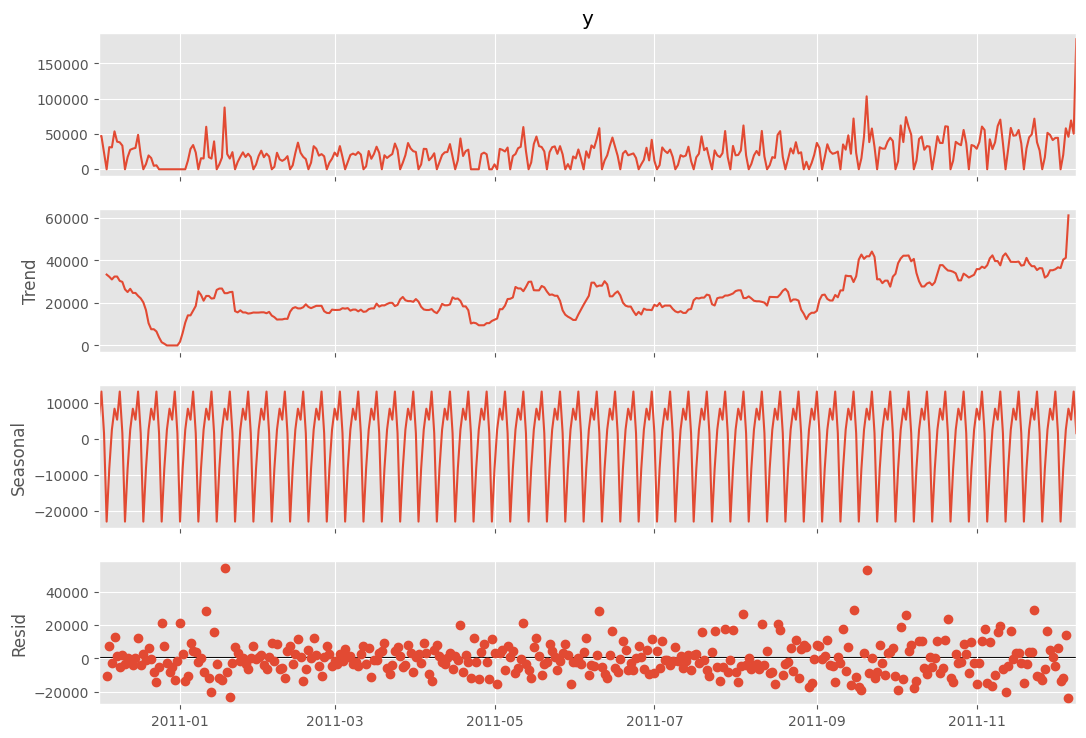

In [14]:
# Set index for decomposition
sales_ts = sales.set_index('ds')['y']

# Additive decomposition
decomposition = seasonal_decompose(sales_ts, model='additive', period=7) # 7-day weekly seasonality

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### 4. Baseline Prophet Model & MLflow Logging
Training the Prophet model and logging the run (Day 7 Checkpoint).

2026/06/17 17:27:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 17:27:54 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Model Evaluation Metrics:
MSE: 162903443.63
RMSE: 12763.36
MAE: 8541.86


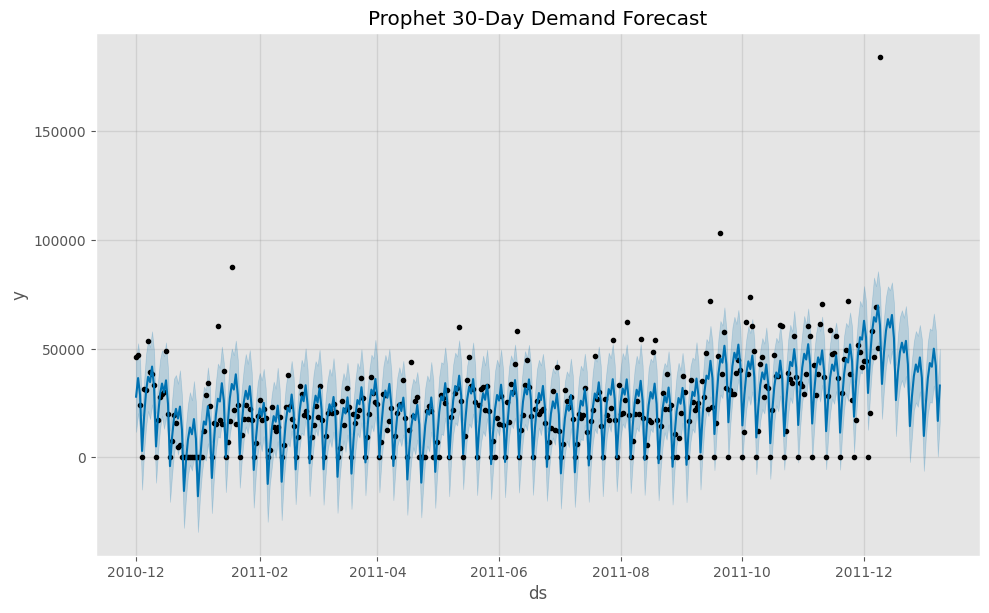

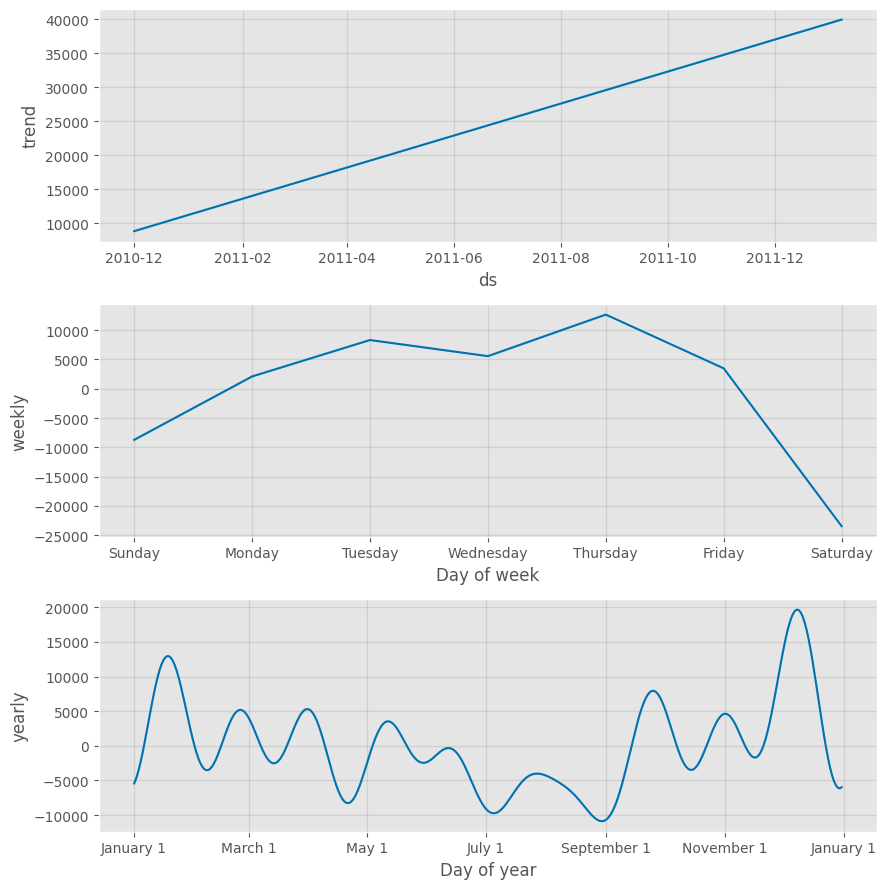


Run successfully logged to MLflow!


In [16]:
# Set MLflow tracking URI to a local SQLite database
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("Demand_Forecasting_Baseline")

with mlflow.start_run(run_name="Prophet_Baseline"):
    # 1. Initialize and train Prophet
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(sales)
    
    # 2. Make future predictions (30 days)
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    # 3. Calculate metrics on historical data
    # Prophet provides 'yhat' for historical dates. We compare y and yhat.
    historical_forecast = forecast[['ds', 'yhat']].head(len(sales))
    actual = sales['y']
    predictions = historical_forecast['yhat']
    
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predictions)
    
    print(f"Model Evaluation Metrics:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    
    # 4. Log params and metrics to MLflow
    mlflow.log_param("model_type", "Prophet")
    mlflow.log_param("forecast_horizon_days", 30)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    
    # 5. Log the Prophet model natively
    mlflow.prophet.log_model(model, artifact_path="prophet_model")
    
    # 6. Plot the forecast
    fig1 = model.plot(forecast)
    plt.title("Prophet 30-Day Demand Forecast")
    plt.show()
    
    # Plot components
    fig2 = model.plot_components(forecast)
    plt.show()
    
    print("\nRun successfully logged to MLflow!")